## Import all the necessary config files

In [21]:
from config import *
from utils import *
import matplotlib.ticker as mticker
import matplotlib.pyplot as plt

## Run the coral model

In [22]:
# This runs the model once for the number of years selected in the user input files
run_coral_model(PSD_T0, MaxYear)

,Year,Branching_Area (%),Foliose_Area (%),Other_Area (%),total_coral_cover (%)
0,0,1.200000,2.200000,16.300000,19.700000
1,1,1.174153,2.374657,16.834479,20.383290
2,2,1.190476,2.645060,17.416332,21.251868
3,3,1.259013,3.072792,18.164551,22.496356
4,4,1.358012,3.672954,19.005438,24.036404
5,5,1.484245,4.433946,19.900478,25.818669
6,6,1.617154,5.321848,21.026611,27.965613
7,7,1.762807,6.323604,22.471380,30.557791
8,8,1.895608,7.417860,23.727556,33.041023
9,9,2.028232,8.583165,24.848358,35.459755


## Plot the change in total coral cover over the years

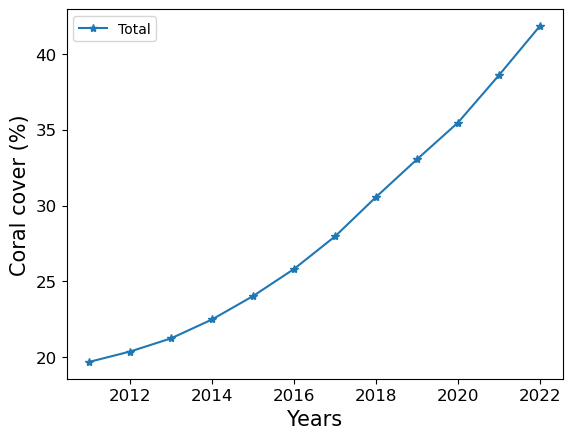

In [23]:
# Build actual years based on row count
n = len(opts.yearly_total_coral_cover_df)
actual_years = range(year_start, year_start + n)

# Plot with actual years as x-values
plt.plot(actual_years,
         opts.yearly_total_coral_cover_df['total_coral_cover (%)'],
         '-*',
         label='Total')

plt.xlabel('Years', fontsize=15)
plt.ylabel('Coral cover (%)', fontsize=15)
plt.legend()

# Make x-axis labels integers only
plt.gca().xaxis.set_major_formatter(mticker.FormatStrFormatter('%d'))

plt.show()

## The benthic cover over the years in percentage

In [24]:
opts.yearly_benthic_cover_df

,Year,total_benthic_cover (%),available_substrate (%),hard_substrate (%),dead_coral (%),CCA (%),turfing_algae (%),macro_algae (%),rubble (%),sediment (%),total_cc,unavailable_sub,tot
0,0,80.300000,72.800000,1.000000,1.000000,8.400000,62.400000,5.500000,1.000000,1.000000,19.700000,6.647223,76.791658
1,1,79.616710,72.255599,0.989338,1.153847,8.402932,61.734700,5.501920,0.833624,1.000349,20.383290,7.333333,99.972222
2,2,78.748132,71.528021,0.976173,1.254307,8.405403,60.913177,5.503538,0.694891,1.000643,21.251868,7.196955,99.976844
3,3,77.503644,70.401084,0.957172,1.326429,8.407497,59.727524,5.504909,0.579220,1.000893,22.496356,7.083257,99.980697
4,4,75.963596,68.959022,0.933598,1.374226,8.409278,58.256528,5.506075,0.482786,1.001105,24.036404,6.988485,99.983911
5,5,74.181331,67.258419,0.906288,1.401092,8.410799,56.552401,5.507071,0.402394,1.001286,25.818669,6.909501,99.986589
6,6,72.034387,65.179524,0.873367,1.406093,8.412104,54.498076,5.507925,0.335381,1.001441,27.965613,6.843685,99.988822
7,7,69.442209,62.644043,0.833605,1.388665,8.413233,52.016946,5.508664,0.279521,1.001575,30.557791,6.788850,99.990684
8,8,66.958977,60.208038,0.795532,1.364068,8.414209,49.641211,5.509303,0.232961,1.001692,33.041023,6.743174,99.992236
9,9,64.540245,57.828644,0.758463,1.332865,8.415052,47.328063,5.509856,0.194154,1.001792,35.459755,6.705129,99.993529


## Plot the benthic cover over the years for turfing algae, dead coral, rubble, macro algae and total coral cover in percentage

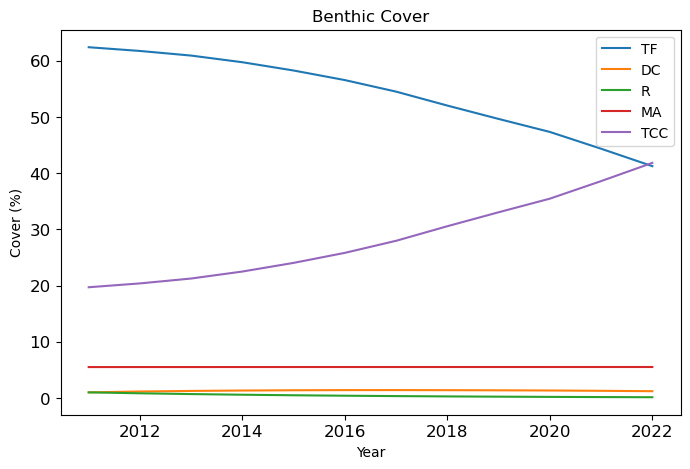

In [25]:
# Make a clean working copy and normalise column names
df = opts.yearly_benthic_cover_df.copy()
df.columns = df.columns.str.strip()

# Replace index with actual years
n = len(df)
actual_years = range(year_start, year_start + n)  # real years
df.index = pd.Index(actual_years, name="Year")

# Create a single plot
fig, ax = plt.subplots(figsize=(8, 5))

ax.plot(df['turfing_algae (%)'], label='TF')
ax.plot(df['dead_coral (%)'], label='DC')
ax.plot(df['rubble (%)'], label='R')
ax.plot(df['macro_algae (%)'], label='MA')
ax.plot(df['total_cc'], label='TCC')

ax.set_xlabel('Year')
ax.set_ylabel('Cover (%)')
ax.set_title('Benthic Cover')
ax.legend()

# Force integer year labels
ax.xaxis.set_major_formatter(mticker.FormatStrFormatter('%d'))

plt.show()

## Export the data frames to excel

In [26]:
# This function exports data frames to Excel 

export_to_excel(opts.yearly_population_df_list,'yearly_population')
export_to_excel(opts.yearly_surface_area_df_list,'yearly_surface_area')
export_to_excel(opts.yearly_total_coral_cover_df,'yearly_total_coral_cover')
export_to_excel(opts.yearly_benthic_cover_df,'yearly_benthic_cover')

## Plots

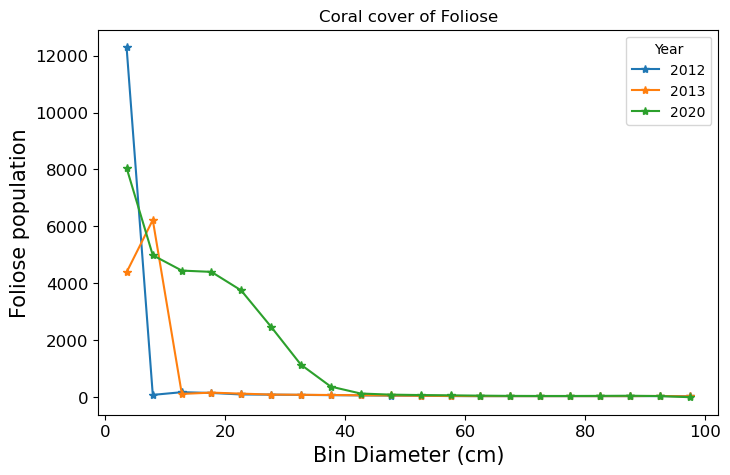

In [28]:
#Coral Cover Population

#Years you want to be plotted:
Years = 2012, 2013, 2020

# Check if any requested years are before the start year
if min(Years) < year_start:
    print(f"Error: Requested year {min(Years)} is before the start year {year_start}. Please use years from {year_start} onwards.")
elif max(Years) > year_end:
    print(f"Error: Requested year {max(Years)} is after the end year {year_end}. Please use years up to {year_end}.")
else:
    # Convert them to model years (indices) for the model
    model_years = tuple(year - year_start for year in Years)
    # Plot coral population change by type
    plot_coral_type_population_change('Foliose', False, *model_years)

(1, 2, 9)


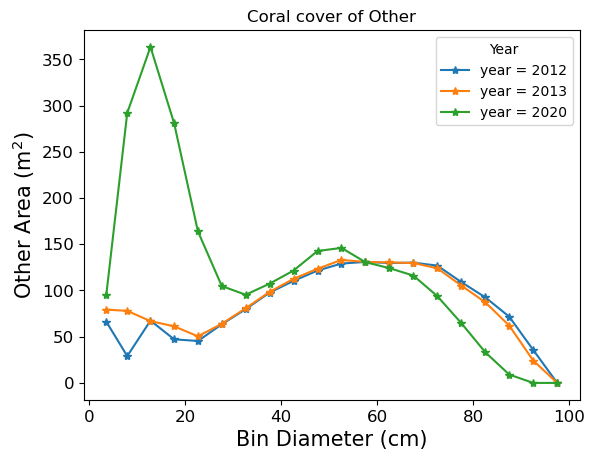

In [29]:
# This plots the Area of the coral type chosen for different input years
# Other

#Years you want to be plotted:
#Years you want to be plotted:
Years = 2012, 2013, 2020

# Check if any requested years are before the start year
if min(Years) < year_start:
    print(f"Error: Requested year {min(Years)} is before the start year {year_start}. Please use years from {year_start} onwards.")
elif max(Years) > year_end:
    print(f"Error: Requested year {max(Years)} is after the end year {year_end}. Please use years up to {year_end}.")
else:
    #Convert them to model years (indices) for the model)
    model_years = tuple(year - year_start for year in Years)

    print(model_years)

    #Plot coral area change by type
    plot_coral_type_areal_change('Other', False, *model_years)

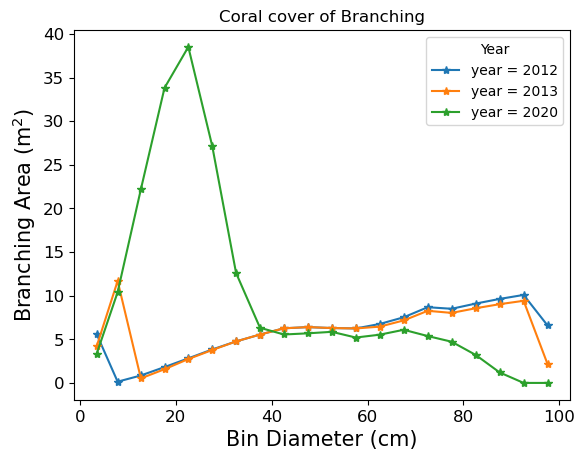

In [30]:
# This plots the Area of the coral type chosen for different input years
# Branching

#Years you want to be plotted:
#Years you want to be plotted:
Years = 2012, 2013, 2020

# Check if any requested years are before the start year
if min(Years) < year_start:
    print(f"Error: Requested year {min(Years)} is before the start year {year_start}. Please use years from {year_start} onwards.")
elif max(Years) > year_end:
    print(f"Error: Requested year {max(Years)} is after the end year {year_end}. Please use years up to {year_end}.")
else:
    #Convert them to model years (indices) for the model)
    model_years = tuple(year - year_start for year in Years)

    plot_coral_type_areal_change('Branching', False, *model_years)

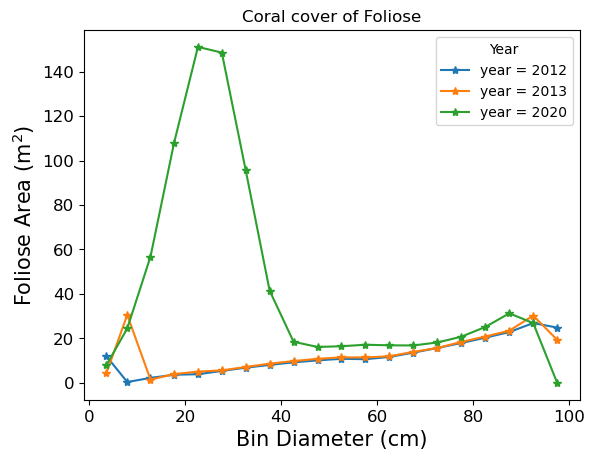

In [31]:
# This plots the Area of the coral type chosen for different input years
# Foliose

#Years you want to be plotted:
#Years you want to be plotted:
Years = 2012, 2013, 2020

# Check if any requested years are before the start year
if min(Years) < year_start:
    print(f"Error: Requested year {min(Years)} is before the start year {year_start}. Please use years from {year_start} onwards.")
elif max(Years) > year_end:
    print(f"Error: Requested year {max(Years)} is after the end year {year_end}. Please use years up to {year_end}.")
else:

    #Convert them to model years (indices) for the model)
    model_years = tuple(year - year_start for year in Years)

    plot_coral_type_areal_change('Foliose',False, *model_years)

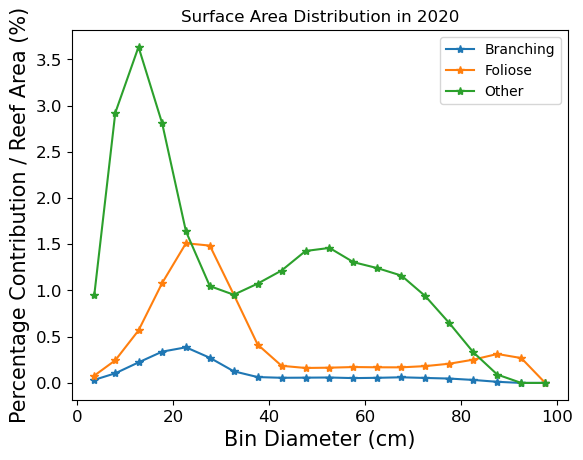

In [32]:
# Plot surface area distribution of different coral types in a given year.

Year = 2020

# Check if the year is within the valid range
if Year < year_start:
    print(f"Error: Requested year {Year} is before the start year {year_start}. Please use years from {year_start} onwards.")
elif Year > year_end:
    print(f"Error: Requested year {Year} is after the end year {year_end}. Please use years up to {year_end}.")
else:
    
    #Convert them to model years (indices) for the model)
    model_year = Year - year_start

    plot_surface_area_distribution(model_year)

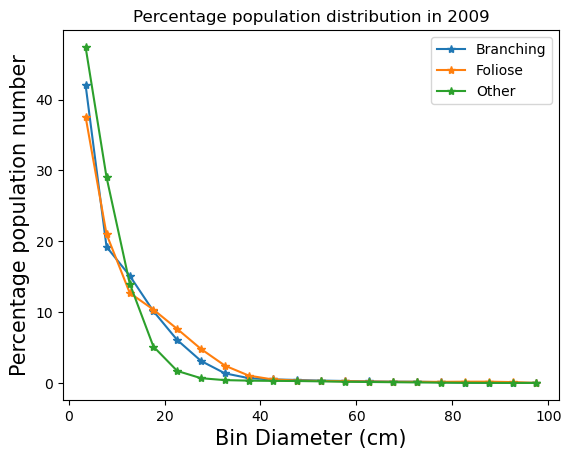

In [13]:
# This function plots the percentage population distribution of the bins in a given year. 
# plot_population_distribution_in_percentage(year)
# For example: 100*branching_population_bin_2/total_branching_population 

Year = 2009
# Check if the year is within the valid range
if Year < year_start:
    print(f"Error: Requested year {Year} is before the start year {year_start}. Please use years from {year_start} onwards.")
elif Year > year_end:
    print(f"Error: Requested year {Year} is after the end year {year_end}. Please use years up to {year_end}.")
else:
    
    #Convert them to model years (indices) for the model)
    model_year = Year - year_start

    plot_population_distribution_in_percentage(model_year)

## Rugosity

In [14]:
# This function calculates the Rugosity and returns them in a list

rugosity_list = get_rugosity_list()
export_to_excel(rugosity_list,'Rugosity')

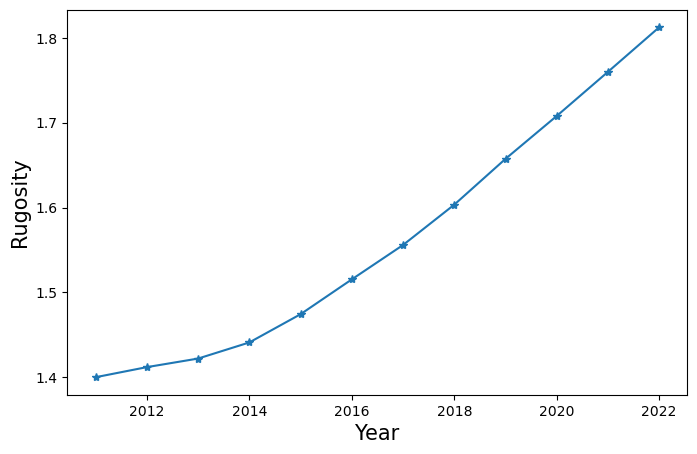

In [15]:
# This function plots the rugosity values over the years

plot_rugosity_year()

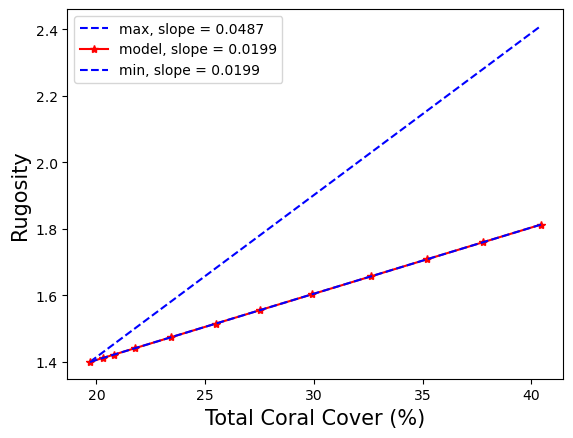

In [16]:
plot_rugosity_total_coral_cover()

## Run simulation for n number of times and plot the total coral cover

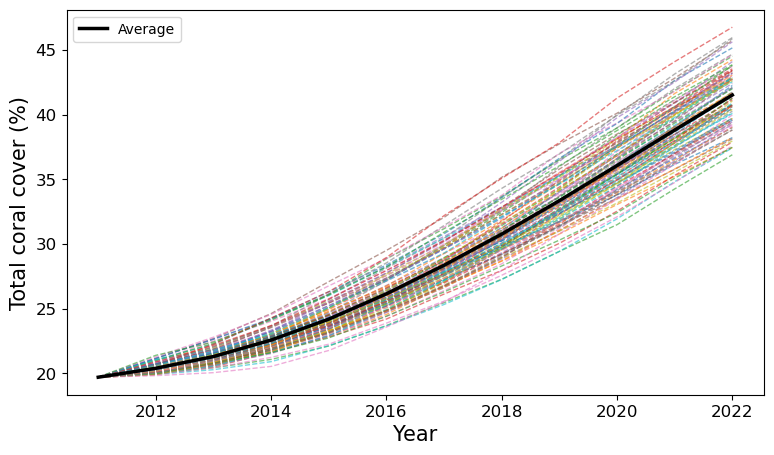

In [17]:
# run the model for n number of iterations (entered in the user inputs)
iteration_df, _ = run_multiple_model_iterations_total_cover(number_of_iterations)

plot_growth_rate_iterations(iteration_df)

In [18]:
iteration_df

,year,iteration_1,iteration_2,iteration_3,iteration_4,iteration_5,iteration_6,iteration_7,iteration_8,iteration_9,...,iteration_92,iteration_93,iteration_94,iteration_95,iteration_96,iteration_97,iteration_98,iteration_99,iteration_100,averaged
0,0,19.700000,19.700000,19.700000,19.700000,19.700000,19.700000,19.700000,19.700000,19.700000,...,19.700000,19.700000,19.700000,19.700000,19.700000,19.700000,19.700000,19.700000,19.700000,19.700000
1,1,20.212731,19.897836,19.963878,20.060266,20.463342,20.698765,20.844820,20.331120,20.113643,...,19.906760,19.970387,20.876707,20.248712,20.077751,19.823694,20.012396,20.556107,20.612911,20.391757
2,2,21.356015,20.642340,20.429857,20.490069,21.144891,21.784740,21.845296,21.115670,20.692357,...,20.746983,20.775294,22.169188,21.229166,20.764140,20.053670,20.958951,21.462773,21.719980,21.299364
3,3,22.460591,21.626606,21.079291,21.621717,22.253187,23.172407,23.249180,22.231490,21.633694,...,21.693561,21.598322,23.697338,22.547093,21.929780,20.536827,22.086250,22.565137,23.098040,22.575875
4,4,23.744373,22.883361,22.114358,22.811723,23.692606,25.117446,24.942812,23.866807,23.501783,...,23.329526,22.740595,25.750859,24.101396,23.136946,21.770501,23.431441,23.981632,25.085136,24.193841
5,5,25.553666,24.557849,23.698045,24.202535,25.328246,27.245551,27.136577,25.856407,25.443023,...,24.819534,24.420434,27.957789,25.849083,24.850852,23.585595,25.529377,25.798955,27.153689,26.150885
6,6,27.263222,26.756022,25.464817,26.133368,27.092899,29.900412,29.271898,28.371223,27.587287,...,26.703155,26.296505,30.233176,27.991198,26.735238,25.520708,27.556617,27.713481,29.307731,28.363410
7,7,29.224891,28.678784,27.278135,27.960754,29.330361,32.573417,31.507867,30.745000,30.336593,...,28.710348,28.308194,32.859645,30.358398,29.007199,27.952448,29.627310,29.933360,32.087049,30.772421
8,8,31.371473,30.778920,29.434259,30.058464,31.723891,35.325000,33.901653,33.181757,33.161474,...,31.074887,30.307553,35.462268,32.635002,31.430967,30.795639,31.749289,32.221146,34.622688,33.358269
9,9,34.237204,33.061787,31.500347,32.544985,34.056906,37.814752,36.395901,36.207857,36.646708,...,33.480591,32.422738,38.139328,35.747564,33.830064,33.471804,34.023370,34.748705,37.232811,36.073906


## Predicting the effect of a cyclone on the whole colony mortality

In [19]:
# This calculation does not use the existing cyclone data from the past, but rather predicts a hypothetical effect of a cyclone on the colony
# to it is possible to assess the effect even if no cyclone data exists for this location
# WCM_rates are the background whole colony mortality rates under no external stressor
# WCM_rates_during_cyclone is the calculated whole colony mortality rates during cyclone

cyclone = True
cyclone_severity_level = 1
distance_to_cyclone = 106

WCM_rates_during_cyclone = get_WCM_rates_after_cyclones(WCM_rates, cyclone_severity_level, distance_to_cyclone)
WCM_rates_during_cyclone

,Branching,Foliose,Other
0,0.200,0.20,0.20
1,0.148,0.04,0.04
2,0.148,0.04,0.04
3,0.076,0.04,0.04
4,0.076,0.02,0.02
5,0.076,0.02,0.02
6,0.076,0.02,0.02
7,0.076,0.02,0.02
8,0.076,0.02,0.02
9,0.076,0.02,0.02


## The effect of bleaching on the partial colony mortality

In [20]:
# PCM_rates are the background partial colony mortality rates under no external stressor
# PCM_rates_during_bleaching is the calculated partial colony mortality rates during bleaching event

branching_bleaching_rate = 34
foliose_bleaching_rate = 17
other_bleaching_rate = 17

dhw = 8

PCM_rates_during_bleaching = get_PCM_rates_after_dhw(PCM_rates, dhw, branching_bleaching_rate, foliose_bleaching_rate, other_bleaching_rate)
PCM_rates_during_bleaching

,Branching,Foliose,Other
0,0.045769,0.069191,0.069191
1,0.053031,0.079560,0.079560
2,0.061146,0.091550,0.091550
3,0.070301,0.105362,0.105362
4,0.080721,0.121340,0.121340
5,0.092685,0.139881,0.139881
6,0.106436,0.161433,0.161433
7,0.122564,0.186486,0.186486
8,0.141452,0.215550,0.215550
9,0.163651,0.249117,0.249117
